# Negative Binomial Regression — BMWP Prediction

The BMWP/Col index is an over-dispersed count, so a negative binomial GLM is used.
The selected model is validated with leave-one-out cross-validation (LOOCV) and its
predictions are mapped onto the five BMWP/Col quality classes.

## 1. Introduction

A negative binomial GLM predicts the BMWP/Col water-quality index from a single
physicochemical predictor selected by AIC (`Dureza`, total hardness). The model is
evaluated under LOOCV, with continuous predictions mapped to the five English quality
classes (Very critical, Critical, Doubtful, Acceptable, Good). Both class-level
metrics (confusion matrices, Cohen's κ) and numerical metrics (MAE, RMSE, R²,
Spearman) are reported.

## 2. Dependencies and Data Loading

The BMWP dataset (n = 18) provides the physicochemical predictors and the continuous
`BMWP` index per sampling station.

In [1]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (confusion_matrix, classification_report, cohen_kappa_score,
                             accuracy_score, precision_recall_fscore_support,
                             mean_absolute_error, r2_score)
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# Load the BMWP dataset (relative path)
df = pd.read_excel("../../data/Database - BMWP.xlsx")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print(df[['Estación', 'Dureza', 'BMWP']].head())

Shape: (18, 24)
  Estación  Dureza  BMWP
0      RF2    35.5    52
1      RC2    49.4    45
2      RA3   113.0    28
3      RA2    98.4    72
4      RA3   108.0    56


## 3. Predictor Selection

BMWP is heavily over-dispersed (variance ≫ mean), justifying a negative binomial GLM
over Poisson. Seven candidate predictors are screened by AIC; the single predictor
`Dureza` (total hardness) gives the lowest AIC.

In [3]:
# Overdispersion check: variance / mean ratio
mean_bmwp, var_bmwp = df['BMWP'].mean(), df['BMWP'].var()
print(f"BMWP mean = {mean_bmwp:.2f}, variance = {var_bmwp:.2f}, ratio = {var_bmwp / mean_bmwp:.2f}")

BMWP mean = 60.06, variance = 1028.76, ratio = 17.13


In [4]:
# Exhaustive AIC-based subset selection for a negative binomial GLM
predictors = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']

def select_model(dataframe, predictors, response):
    best_aic, best_combination, best_model = np.inf, None, None
    for L in range(1, len(predictors) + 1):
        for subset in combinations(predictors, L):
            X_subset = sm.add_constant(dataframe[list(subset)])
            result = sm.GLM(dataframe[response], X_subset, family=sm.families.NegativeBinomial()).fit()
            if result.aic < best_aic:
                best_aic, best_combination, best_model = result.aic, subset, result
    print(f"Best subset: {best_combination} (AIC = {best_aic:.3f})")
    return best_model

best_model = select_model(df, predictors, ['BMWP'])
print(best_model.summary())

Best subset: ('Dureza',) (AIC = 185.794)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   BMWP   No. Observations:                   18
Model:                            GLM   Df Residuals:                       16
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.897
Date:                Tue, 23 Jun 2026   Deviance:                       5.0186
Time:                        16:13:01   Pearson chi2:                     4.01
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1019
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      

## 4. Model Definition

A negative binomial GLM with `Dureza` as predictor. Continuous BMWP predictions are
categorised into quality classes using the standard Roldán (1996) BMWP/Col
thresholds (fixed reference values, independent of the data, so they introduce no
leakage):

| Predicted BMWP | Quality class |
|----------------|---------------|
| 101 – 120      | Good          |
| 61 – 100       | Acceptable    |
| 36 – 60        | Doubtful      |
| 16 – 35        | Critical      |
| 0 – 15         | Very critical |

In [5]:
# BMWP/Col quality classes (English) and the categorisation function
bmwp_classes = {
    'Very critical': (0, 15),
    'Critical': (16, 35),
    'Doubtful': (36, 60),
    'Acceptable': (61, 100),
    'Good': (101, 120),
}
labels = list(bmwp_classes.keys())   # worst -> best

def classify_bmwp(value):
    # Map a continuous BMWP value to its quality class label (None if out of range)
    for label, (lower, upper) in bmwp_classes.items():
        if lower <= value <= upper:
            return label
    return None

# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
                xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=14); plt.xlabel('Predicted', fontsize=12); plt.ylabel('Observed', fontsize=12)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

In [6]:
# LOOCV of the negative binomial model with Dureza; collect continuous predictions
X = df[['Dureza']]
y = df['BMWP']
loo = LeaveOneOut()
y_true_val, y_pred_val, y_true_cal, y_pred_cal = [], [], [], []
for tr, te in loo.split(X):
    X_train_const = sm.add_constant(X.iloc[tr], has_constant='add')
    X_val_const = sm.add_constant(X.iloc[te], has_constant='add')
    results = sm.GLM(y.iloc[tr], X_train_const, family=sm.families.NegativeBinomial()).fit()
    y_pred_cal += results.predict(X_train_const).tolist()
    y_true_cal += y.iloc[tr].tolist()
    y_pred_val.append(results.predict(X_val_const).iloc[0])
    y_true_val.append(y.iloc[te].iloc[0])

# Map continuous predictions to BMWP classes, dropping any out-of-range entries
def to_classes(true_vals, pred_vals):
    tc = [classify_bmwp(v) for v in true_vals]
    pc = [classify_bmwp(v) for v in pred_vals]
    idx = [i for i, (t, p) in enumerate(zip(tc, pc)) if t is not None and p is not None]
    return [tc[i] for i in idx], [pc[i] for i in idx]

y_true_cal_class, y_pred_cal_class = to_classes(y_true_cal, y_pred_cal)
y_true_val_class, y_pred_val_class = to_classes(y_true_val, y_pred_val)
print("Predicted BMWP range (validation):",
      f"{min(y_pred_val):.1f} - {max(y_pred_val):.1f}")
print("Classes present (validation):", sorted(set(y_true_val_class) | set(y_pred_val_class)))

Predicted BMWP range (validation): 11.7 - 88.6
Classes present (validation): ['Acceptable', 'Critical', 'Doubtful', 'Good', 'Very critical']


## 5. Evaluation — Calibration

Calibration confusion matrix and report aggregate the training-fold predictions
across all LOOCV folds (English class labels).

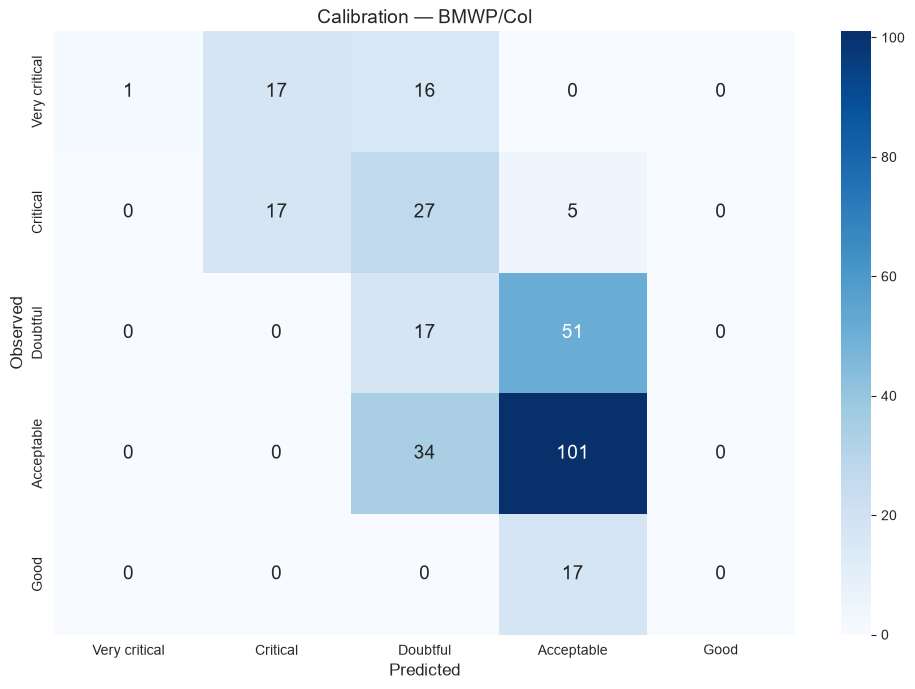

               precision    recall  f1-score   support

Very critical       1.00      0.03      0.06        34
     Critical       0.50      0.35      0.41        49
     Doubtful       0.18      0.25      0.21        68
   Acceptable       0.58      0.75      0.65       135
         Good       0.00      0.00      0.00        17

     accuracy                           0.45       303
    macro avg       0.45      0.27      0.27       303
 weighted avg       0.49      0.45      0.41       303

Cohen's Kappa (calibration): 0.160


In [7]:
# Calibration confusion matrix, classification report, Cohen's kappa
plot_confusion(y_true_cal_class, y_pred_cal_class, 'Calibration — BMWP/Col',
               'nbr_bmwp_confusion_matrix_calibration.png')
print(classification_report(y_true_cal_class, y_pred_cal_class, labels=labels, zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(y_true_cal_class, y_pred_cal_class):.3f}")

## 6. Evaluation — Validation (LOOCV)

Validation confusion matrix and report use the held-out observation from each fold
(English class labels).

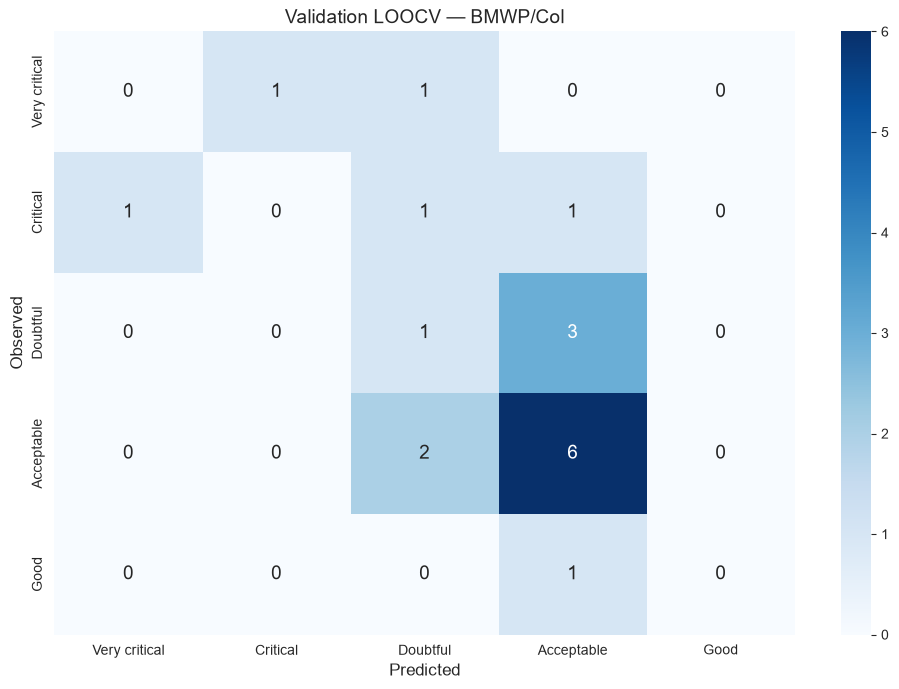

               precision    recall  f1-score   support

Very critical       0.00      0.00      0.00         2
     Critical       0.00      0.00      0.00         3
     Doubtful       0.20      0.25      0.22         4
   Acceptable       0.55      0.75      0.63         8
         Good       0.00      0.00      0.00         1

     accuracy                           0.39        18
    macro avg       0.15      0.20      0.17        18
 weighted avg       0.29      0.39      0.33        18

Cohen's Kappa (validation): 0.062


In [8]:
# Validation confusion matrix, classification report, Cohen's kappa
plot_confusion(y_true_val_class, y_pred_val_class, 'Validation LOOCV — BMWP/Col',
               'nbr_bmwp_confusion_matrix_validation.png')
print(classification_report(y_true_val_class, y_pred_val_class, labels=labels, zero_division=0))
kappa_bmwp = cohen_kappa_score(y_true_val_class, y_pred_val_class)
print(f"Cohen's Kappa (validation): {kappa_bmwp:.3f}")

## 7. Numerical Performance

Numerical accuracy of the continuous BMWP predictions (before categorisation) against
the observed BMWP/Col index over all 18 LOOCV folds.

In [9]:
# Numerical metrics on the raw continuous predictions (before categorisation)
y_true_arr = np.array(y_true_val, dtype=float)
y_pred_arr = np.array(y_pred_val, dtype=float)
mae = mean_absolute_error(y_true_arr, y_pred_arr)
rmse = float(np.sqrt(np.mean((y_true_arr - y_pred_arr) ** 2)))
r2 = r2_score(y_true_arr, y_pred_arr)
rs, p = spearmanr(y_true_arr, y_pred_arr)

print(f"=== NBR Numerical Performance (LOOCV, n=18) ===")
print(f"MAE:  {mae:.2f} BMWP points")
print(f"RMSE: {rmse:.2f} BMWP points")
print(f"R²:   {r2:.3f}")
print(f"Spearman rs: {rs:.3f} (p = {p:.4f})")

# Persist numerical metrics for the master results table
pd.DataFrame([{'model': 'NBR', 'validation': 'LOOCV', 'n': 18,
               'mae': round(mae, 2), 'rmse': round(rmse, 2), 'r2': round(r2, 3),
               'rs': round(rs, 3), 'p_value': round(p, 4)}]
             ).to_csv("../../outputs/numerical_bmwp_nbr.csv", index=False)
print("Saved outputs/numerical_bmwp_nbr.csv")

=== NBR Numerical Performance (LOOCV, n=18) ===
MAE:  27.43 BMWP points
RMSE: 30.18 BMWP points
R²:   0.063
Spearman rs: 0.344 (p = 0.1626)
Saved outputs/numerical_bmwp_nbr.csv


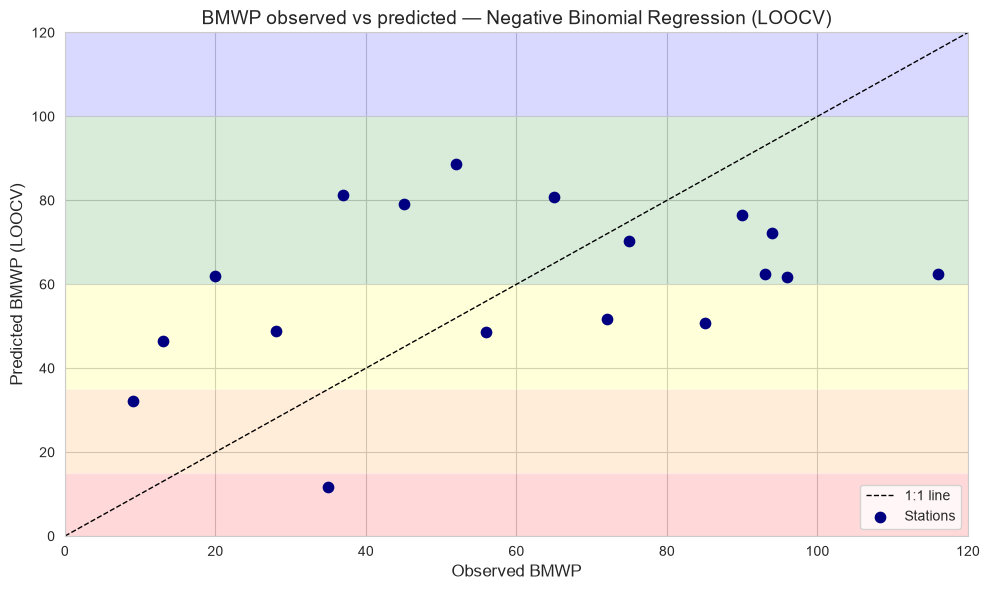

In [10]:
# Observed vs predicted BMWP scatter (LOOCV) with 1:1 line and quality-band backgrounds
bands = [(0, 15, 'red'), (15, 35, 'darkorange'), (35, 60, 'yellow'),
         (60, 100, 'green'), (100, 120, 'blue')]
plt.figure(figsize=(10, 6))
for lo, hi, col in bands:
    plt.axhspan(lo, hi, facecolor=col, alpha=0.15)
plt.plot([0, 120], [0, 120], 'k--', linewidth=1, label='1:1 line')
plt.scatter(y_true_arr, y_pred_arr, color='navy', s=55, zorder=3, label='Stations')
plt.xlim(0, 120); plt.ylim(0, 120)
plt.xlabel('Observed BMWP', fontsize=12); plt.ylabel('Predicted BMWP (LOOCV)', fontsize=12)
plt.title('BMWP observed vs predicted — Negative Binomial Regression (LOOCV)', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig("../../outputs/nbr_bmwp_observed_vs_predicted.png", dpi=300); plt.show()

## 8. Visualisation

Fitted negative binomial curve of BMWP as a function of total hardness, refitted on
the full sample for display.

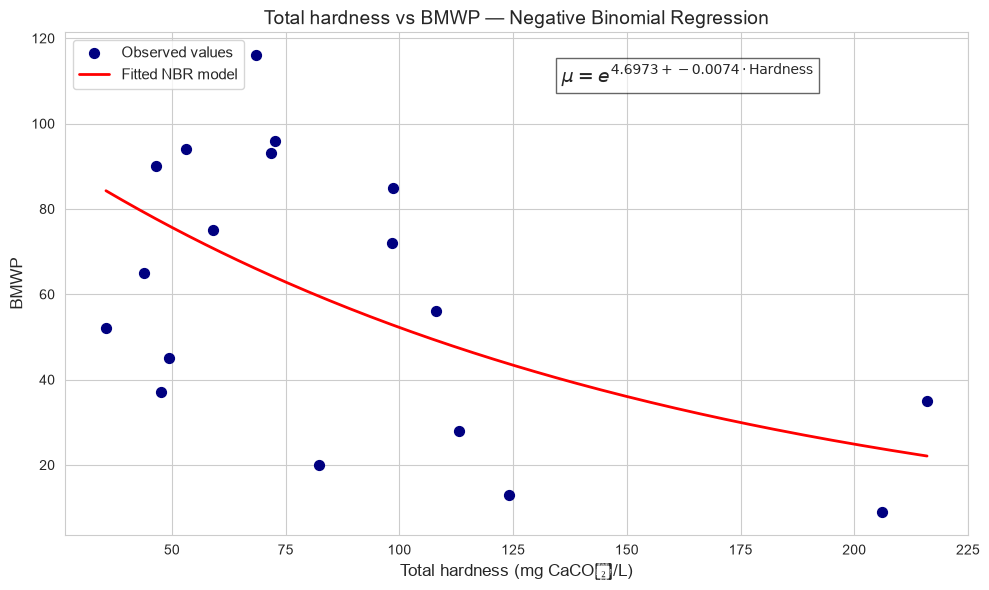

In [11]:
# Fitted NBR curve: BMWP vs total hardness (full-sample fit)
X_full = sm.add_constant(df[['Dureza']], has_constant='add')
results = sm.GLM(df['BMWP'], X_full, family=sm.families.NegativeBinomial()).fit()
b0, b1 = results.params['const'], results.params['Dureza']
x_grid = np.linspace(df['Dureza'].min(), df['Dureza'].max(), 200)
X_pred = sm.add_constant(pd.DataFrame({'Dureza': x_grid}), has_constant='add')
y_grid = results.predict(X_pred)

plt.figure(figsize=(10, 6))
plt.scatter(df['Dureza'], df['BMWP'], color='navy', s=50, label='Observed values')
plt.plot(x_grid, y_grid, color='red', linewidth=2, label='Fitted NBR model')
plt.xlabel('Total hardness (mg CaCO₃/L)', fontsize=12); plt.ylabel('BMWP', fontsize=12)
plt.title('Total hardness vs BMWP — Negative Binomial Regression', fontsize=14)
equation = rf"$\mu = e^{{{b0:.4f} + {b1:.4f} \cdot \mathrm{{Hardness}}}}$"
plt.text(0.55, 0.9, equation, transform=plt.gca().transAxes, fontsize=14,
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.6))
plt.legend(fontsize=11)
plt.tight_layout(); plt.savefig("../../outputs/nbr_fitted_curve_bmwp_vs_hardness.png", dpi=300); plt.show()

In [12]:
# Export class-level validation metrics for the master results table
present = [c for c in labels if c in y_true_val_class]
prec, rec, f1m, _ = precision_recall_fscore_support(
    y_true_val_class, y_pred_val_class, labels=present, average='macro', zero_division=0)
acc_bmwp = accuracy_score(y_true_val_class, y_pred_val_class)
pd.DataFrame([{'target': 'BMWP', 'technique': 'Negative binomial reg.', 'validation': 'LOOCV', 'n': 18,
               'precision': round(prec, 3), 'recall': round(rec, 3), 'f1': round(f1m, 3),
               'accuracy': round(acc_bmwp, 3), 'kappa': round(kappa_bmwp, 3)}]
             ).to_csv("../../outputs/metrics_nb.csv", index=False)
print(f"BMWP LOOCV (NBR): accuracy = {acc_bmwp:.3f}, Cohen's Kappa = {kappa_bmwp:.3f}")
print("Saved outputs/metrics_nb.csv")

BMWP LOOCV (NBR): accuracy = 0.389, Cohen's Kappa = 0.062
Saved outputs/metrics_nb.csv


## 9. Limitations

- **Single predictor on a small sample.** With one predictor (`Dureza`) and n = 18,
  the negative binomial model captures only the broad hardness–BMWP trend; numerical
  error (MAE/RMSE on the 0–120 scale) is large and R² is low.
- **Class collapse.** Mapping continuous predictions to five classes concentrates
  predictions into the central classes, so several quality classes are never
  predicted; class-level κ is correspondingly low.
- **Spatial non-independence.** Stations lie along one river, so LOOCV folds are not
  fully independent.
- **Threshold gaps.** The Roldán thresholds leave a one-point gap between Acceptable
  (≤100) and Good (≥101); predictions falling in (100, 101) would be dropped, though
  none occur here.